# Joint LightGBM + temporal edge-aware relation-aware GraphSAGE

This notebook runs the final four controlled experiments:

1. fixed training alpha = 0.80 with BCE;
2. fixed training alpha = 0.85 with BCE;
3. fixed training alpha = 0.90 with BCE;
4. fixed training alpha = 0.80 with pairwise AUC-ranking loss.

Reusable preprocessing, graph, sampling, model, evaluation, persistence, and plotting helpers are imported from:

```text
src/Joint_LGBM_GNN_models/
```

Repository layout expected by this notebook:

```text
root/
├── data/
├── notebooks/
│   └── joint_lgbm_gnn.ipynb
├── src/
│   └── Joint_LGBM_GNN_models/
│       ├── saved_results/
│       └── helper modules
└── README.md
```

The experiment logic, training orchestration, and plotting calls remain visible in this notebook.


## Repository layout

This notebook reads data from `../data/`, imports reusable code from `../src/Joint_LGBM_GNN_models/`, and writes checkpoints, histories, predictions, tables, and plots to `../src/Joint_LGBM_GNN_models/saved_results/`.


## 0. Environment


In [ ]:
# Uncomment in a fresh Colab runtime if needed.
!pip -q install lightgbm torch-geometric


## 1. Imports and configuration


In [ ]:
import os
import sys
import json
import copy
import math
import random
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb

import torch
import torch.nn as nn

from torch_geometric.data import Data

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ------------------------------------------------------------
# Repository paths
# ------------------------------------------------------------
# Supported launch locations:
#   1. repository root
#   2. notebooks/ directory
CWD = Path.cwd().resolve()

if (CWD / "src" / "Joint_LGBM_GNN_models").exists():
    REPO_ROOT = CWD
elif (CWD.parent / "src" / "Joint_LGBM_GNN_models").exists():
    REPO_ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Could not locate src/Joint_LGBM_GNN_models. "
        "Run the notebook from the repository root or notebooks/."
    )

NOTEBOOK_DIR = REPO_ROOT / "notebooks"
DATA_DIR = REPO_ROOT / "data"
SRC_DIR = REPO_ROOT / "src"
RESULTS_DIR = SRC_DIR / "Joint_LGBM_GNN_models" / "saved_results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

SUBSAMPLE = None  # set to an integer for a quick pilot


# ------------------------------------------------------------
# Project helper imports
# ------------------------------------------------------------
from Joint_LGBM_GNN_models import (
    JointLightGBMTemporalRelationAwareGraphSAGE,
    RelationAwareIncomingNeighborLoader,
    add_fused_probability,
    add_uid,
    build_past_only_toper_features,
    build_split_aware_relation_graph,
    cpu_state_dict,
    create_model_and_optimizer,
    evaluate_loader,
    fit_lgb_train_only,
    fusion_metrics_from_pred_df,
    grad_norm_from_loss,
    make_graphsage_node_features,
    make_lgb_matrix,
    make_lgb_temporal_oof_raw,
    make_temporal_80_10_10_split,
    pairwise_auc_loss,
    plot_history_metric,
    reset_loader_epochs,
    robust_scale_train_only,
    running_past_prior_logits,
    safe_auc,
    safe_pr_auc,
    save_single_experiment_artifacts,
    select_alpha_on_validation,
    set_all_seeds,
    sigmoid_np,
)

# ------------------------------------------------------------
# Strict chronological split
# ------------------------------------------------------------
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
TEST_FRAC = 0.10

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-12


# ------------------------------------------------------------
# LightGBM preprocessing and fitting
# ------------------------------------------------------------
DROP_TRANSACTIONDT_FROM_LGB = False
USE_UID_AS_LGB_FEATURE = False

LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 64,
    'min_data_in_leaf': 100,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 1,
    'lambda_l2': 1.0,
    'verbosity': -1,
    'seed': RANDOM_SEED,
    'num_threads': -1,
    'is_unbalance': True,
}

LGB_INNER_ES_FRAC = 0.10
LGB_MAX_BOOST_ROUNDS = 3000
LGB_EARLY_STOPPING_ROUNDS = 100
LGB_FALLBACK_ROUNDS = 400

OOF_N_SPLITS = 8
OOF_MIN_TRAIN_FRAC = 0.05
OOF_ES_HOLDOUT_FRAC = 0.10


# ------------------------------------------------------------
# GraphSAGE node preprocessing, adapted from the residual notebook
# ------------------------------------------------------------
GRAPHSAGE_TOP_LGB_FEATURES = 64
GRAPHSAGE_FEATURE_CLIP = 8.0
GNN_HIDDEN_DIM = 256
GNN_DROPOUT = 0.20


# ------------------------------------------------------------
# Graph V2
# ------------------------------------------------------------
SECONDS_PER_DAY = 86400.0

# ------------------------------------------------------------
# Residual-topology relation families
# ------------------------------------------------------------

# Exact TopER relation recipes from the residual-topology notebook.
# These are used only to build the six past-only TopER structural features.
TOPER_RELATION_SPECS = [
    {
        'name': 'UID_1d',
        'cols': ['UID'],
        'min_age_days': 0.0,
        'window_days': 1.0,
        'max_history': 80,
    },
    {
        'name': 'card1_addr1_1d',
        'cols': ['card1', 'addr1'],
        'min_age_days': 0.0,
        'window_days': 1.0,
        'max_history': 80,
    },
    {
        'name': 'card1_Pemail_1d',
        'cols': ['card1', 'P_emaildomain'],
        'min_age_days': 0.0,
        'window_days': 1.0,
        'max_history': 80,
    },
    {
        'name': 'card1_ProductCD_1d',
        'cols': ['card1', 'ProductCD'],
        'min_age_days': 0.0,
        'window_days': 1.0,
        'max_history': 80,
    },
    {
        'name': 'card1_DeviceInfo_1d',
        'cols': ['card1', 'DeviceInfo'],
        'min_age_days': 0.0,
        'window_days': 1.0,
        'max_history': 80,
    },

    {
        'name': 'UID_3d',
        'cols': ['UID'],
        'min_age_days': 0.0,
        'window_days': 3.0,
        'max_history': 80,
    },
    {
        'name': 'card1_addr1_3d',
        'cols': ['card1', 'addr1'],
        'min_age_days': 0.0,
        'window_days': 3.0,
        'max_history': 80,
    },
    {
        'name': 'card1_Pemail_3d',
        'cols': ['card1', 'P_emaildomain'],
        'min_age_days': 0.0,
        'window_days': 3.0,
        'max_history': 80,
    },
    {
        'name': 'card1_ProductCD_3d',
        'cols': ['card1', 'ProductCD'],
        'min_age_days': 0.0,
        'window_days': 3.0,
        'max_history': 80,
    },
    {
        'name': 'card1_DeviceInfo_3d',
        'cols': ['card1', 'DeviceInfo'],
        'min_age_days': 0.0,
        'window_days': 3.0,
        'max_history': 80,
    },

    {
        'name': 'UID_7d_small',
        'cols': ['UID'],
        'min_age_days': 0.0,
        'window_days': 7.0,
        'max_history': 80,
    },
    {
        'name': 'card1_addr1_7d_small',
        'cols': ['card1', 'addr1'],
        'min_age_days': 0.0,
        'window_days': 7.0,
        'max_history': 80,
    },
    {
        'name': 'card1_Pemail_7d_small',
        'cols': ['card1', 'P_emaildomain'],
        'min_age_days': 0.0,
        'window_days': 7.0,
        'max_history': 80,
    },
]


# Exact EDA-informed relation recipes from the residual-topology notebook.
# These relations define the GraphSAGE candidate graph.
GRAPH_RELATION_SPECS = [
    {
        'name': 'card_full',
        'cols': ['card1', 'card2', 'card3', 'card4', 'card5', 'card6'],
        'min_age_days': 0.0,
        'window_days': 30.0,
        'max_history': 50,
    },
    {
        'name': 'card_addr',
        'cols': ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2'],
        'min_age_days': 0.0,
        'window_days': 30.0,
        'max_history': 50,
    },
    {
        'name': 'card_email',
        'cols': ['card1', 'card2', 'card3', 'card5', 'P_emaildomain'],
        'min_age_days': 0.0,
        'window_days': 30.0,
        'max_history': 50,
    },
    {
        'name': 'addr_email',
        'cols': ['addr1', 'addr2', 'P_emaildomain'],
        'min_age_days': 0.0,
        'window_days': 14.0,
        'max_history': 40,
    },
    {
        'name': 'device_addr',
        'cols': ['DeviceType', 'DeviceInfo', 'addr1', 'addr2'],
        'min_age_days': 0.0,
        'window_days': 30.0,
        'max_history': 40,
    },
    {
        'name': 'uid',
        'cols': ['UID'],
        'min_age_days': 0.0,
        'window_days': 30.0,
        'max_history': 50,
    },
]

TRAIN_RELATION_FANOUTS = [2, 1]
EVAL_RELATION_FANOUTS = [3, 1]

# Relation-aware message passing.
# Each GraphSAGE relation is aggregated separately and then combined with
# node-specific relation attention.
RELATION_ATTENTION_HIDDEN_DIM = 32

# Fixed temporal decay constants for sampled relation edges.
# The 30-day graph relations use tau=10 days; the 14-day addr_email
# relation uses tau=5 days. Sampling itself remains unchanged.
RELATION_TAU_DAYS = {
    'card_full': 10.0,
    'card_addr': 10.0,
    'card_email': 10.0,
    'addr_email': 5.0,
    'device_addr': 10.0,
    'uid': 10.0,
}


# ------------------------------------------------------------
# Past-only TopER-style structural features
# ------------------------------------------------------------
TOPER_FEATURES_ENABLED = True
TOPER_CLIP_Z = 8.0

TOPER_RAW_FEATURE_NAMES = [
    'toper_hist_n',
    'toper_active_relations',
    'toper_graph_m',
    'toper_beta0',
    'toper_beta1',
    'toper_density',
]

TOPER_MODEL_FEATURE_NAMES = [
    'toper_log_hist_n',
    'toper_active_rel_frac',
    'toper_log_graph_m',
    'toper_log_beta0',
    'toper_log_beta1',
    'toper_density',
]


# ------------------------------------------------------------
# Batch sizes and natural seed sampling
# ------------------------------------------------------------
TRAIN_BATCH_SIZE = 2048
EVAL_BATCH_SIZE = 4096

# Design 1 baseline: no positive-seed oversampling.
# Every training node is used once per epoch, in shuffled order.
ENABLE_POSITIVE_SEED_OVERSAMPLING = False
TARGET_POSITIVE_SEED_RATE = None
TRAIN_SEEDS_PER_EPOCH = None


# ------------------------------------------------------------
# Learned global logit fusion and joint optimization
# ------------------------------------------------------------
ALPHA_INIT = 0.50
ALPHA_WARMUP_EPOCHS = 3
ALPHA_LR = 1e-4

EXPERIMENT_SPECS = [
    {
        'name': 'fixed_alpha_080',
        'fixed_alpha': 0.80,
        'main_loss_type': 'bce',
    },
    {
        'name': 'fixed_alpha_085',
        'fixed_alpha': 0.85,
        'main_loss_type': 'bce',
    },
    {
        'name': 'fixed_alpha_090',
        'fixed_alpha': 0.90,
        'main_loss_type': 'bce',
    },
    {
        'name': 'fixed_alpha_080_auc_rank',
        'fixed_alpha': 0.80,
        'main_loss_type': 'pairwise_auc',
    },
]

# Pairwise ranking-loss pair budget per training batch.
# Uniform positive-negative pairs are sampled when all pairs exceed this cap.
AUC_RANK_MAX_PAIRS = 8192

# Fine global-alpha grid. ROC-AUC-optimal and PR-AUC-optimal
# alphas are tracked independently on validation every epoch.
ALPHA_GRID = np.round(np.linspace(0.0, 1.0, 101), 2)
CHECKPOINT_METRIC = 'auc'  # 'auc' or 'pr'

EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0

LAMBDA_GNN = 0.10

PATIENCE = 15
MIN_DELTA = 1e-4


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


## 2. Load, merge, sort, create UID, and make the strict temporal 80/10/10 split

The split is purely chronological. The approximate 80% and 90% cut positions are moved to nearby timestamp-group boundaries to prevent equal timestamps from appearing on both sides of a boundary.


In [ ]:
transaction_path = DATA_DIR / "train_transaction.csv"
identity_path = DATA_DIR / "train_identity.csv"

if not transaction_path.exists() or not identity_path.exists():
    raise FileNotFoundError(
        "Expected IEEE-CIS training files under data/: "
        f"{transaction_path} and {identity_path}"
    )

trans = pd.read_csv(transaction_path)
identity = pd.read_csv(identity_path)

if identity["TransactionID"].duplicated().any():
    raise ValueError(
        "train_identity.csv contains duplicate TransactionID values; "
        "the left merge would change the transaction row count."
    )

df = trans.merge(identity, on='TransactionID', how='left')

if len(df) != len(trans):
    raise RuntimeError(
        "Merged row count differs from train_transaction.csv row count."
    )

print(
    "merge row-count check passed:",
    len(df),
    "rows (same as original train_transaction.csv)",
)

if SUBSAMPLE is not None:
    df = df.iloc[:int(SUBSAMPLE)].copy()

df = add_uid(df)
df_sorted, train_idx_np, val_idx_np, test_idx_np = make_temporal_80_10_10_split(
    df,
    train_frac=TRAIN_FRAC,
    val_frac=VAL_FRAC,
)

y_all = df_sorted['isFraud'].to_numpy(dtype=np.float32)
time_values = df_sorted['TransactionDT'].to_numpy(dtype=np.float64)

train_end = len(train_idx_np)
val_end = train_end + len(val_idx_np)
num_nodes = len(df_sorted)

print(f'transactions: {num_nodes:,}')
print(f'train: {len(train_idx_np):,} ({len(train_idx_np)/num_nodes:.4f}), fraud={y_all[train_idx_np].mean():.5f}')
print(f'val  : {len(val_idx_np):,} ({len(val_idx_np)/num_nodes:.4f}), fraud={y_all[val_idx_np].mean():.5f}')
print(f'test : {len(test_idx_np):,} ({len(test_idx_np)/num_nodes:.4f}), fraud={y_all[test_idx_np].mean():.5f}')

print('\nTransactionDT ranges:')
print('train:', (time_values[train_idx_np].min(), time_values[train_idx_np].max()))
print('val  :', (time_values[val_idx_np].min(), time_values[val_idx_np].max()))
print('test :', (time_values[test_idx_np].min(), time_values[test_idx_np].max()))


## 3. LightGBM preprocessing from the residual-topology notebook

This intentionally replaces the old MLP preprocessing. Categorical mappings are learned from the 80% training period only. Later unseen levels receive code `-1`. Numeric columns remain in native scale and retain missing values for LightGBM.


In [ ]:
X_lgb = make_lgb_matrix(
    df_sorted,
    fit_idx=train_idx_np,
    use_uid_as_lgb_feature=USE_UID_AS_LGB_FEATURE,
    drop_transactiondt=DROP_TRANSACTIONDT_FROM_LGB,
)

print('LightGBM feature matrix:', X_lgb.shape)
print('numeric columns:', X_lgb.select_dtypes(include=['number']).shape[1])
print('all columns numeric after encoding:', all(pd.api.types.is_numeric_dtype(X_lgb[c]) for c in X_lgb.columns))


## 4. Fit LightGBM without using validation or test labels

The 80% training block contains an inner chronological tail used only to choose the number of boosting rounds. The model is then refit on the full 80% training block for that fixed number of rounds.

Temporal OOF raw scores are generated for training nodes with expanding windows. The earliest training prefix, for which no LightGBM OOF model exists, receives a past-only smoothed running-prior logit rather than an in-sample prediction.


In [ ]:
lgb_model, lgb_raw_fullfit_all, lgb_prob_fullfit_all, lgb_best_iteration = fit_lgb_train_only(
    X_lgb,
    y_all,
    train_idx_np,
    time_values,
    params=LGB_PARAMS,
    inner_es_frac=LGB_INNER_ES_FRAC,
    max_boost_rounds=LGB_MAX_BOOST_ROUNDS,
    early_stopping_rounds=LGB_EARLY_STOPPING_ROUNDS,
    fallback_rounds=LGB_FALLBACK_ROUNDS,
)

print('\nBuilding temporal OOF LightGBM raw scores for training nodes...')
lgb_oof_raw = make_lgb_temporal_oof_raw(
    X_lgb,
    y_all,
    train_idx_np,
    time_values,
    params=LGB_PARAMS,
    n_splits=OOF_N_SPLITS,
    min_train_frac=OOF_MIN_TRAIN_FRAC,
    es_holdout_frac=OOF_ES_HOLDOUT_FRAC,
    max_boost_rounds=LGB_MAX_BOOST_ROUNDS,
    early_stopping_rounds=LGB_EARLY_STOPPING_ROUNDS,
    fallback_rounds=LGB_FALLBACK_ROUNDS,
)

prior_raw = running_past_prior_logits(y_all, train_idx_np)

lgb_raw_current_all = lgb_raw_fullfit_all.copy()
missing_oof = train_idx_np[~np.isfinite(lgb_oof_raw[train_idx_np])]
finite_oof = train_idx_np[np.isfinite(lgb_oof_raw[train_idx_np])]

lgb_raw_current_all[finite_oof] = lgb_oof_raw[finite_oof]
lgb_raw_current_all[missing_oof] = prior_raw[missing_oof]
lgb_prob_current_all = sigmoid_np(lgb_raw_current_all).astype(np.float32)

print('training OOF coverage:', len(finite_oof), '/', len(train_idx_np))
print('past-prior fallback rows:', len(missing_oof))

print('\nStandalone LightGBM validation metrics:')
print('val ROC-AUC:', safe_auc(y_all[val_idx_np], lgb_prob_fullfit_all[val_idx_np]))
print('val PR-AUC :', safe_pr_auc(y_all[val_idx_np], lgb_prob_fullfit_all[val_idx_np]))
print('Test metrics are intentionally deferred until the final evaluation cell.')


In [ ]:
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


lgb_model_path = (
    RESULTS_DIR
    / "lightgbm_fraud_model.txt"
)

lgb_model.save_model(
    str(lgb_model_path)
)

print(
    "saved LightGBM model:",
    lgb_model_path,
)


lgb_prediction_df = pd.DataFrame({
    "node_id": np.arange(
        len(df_sorted),
        dtype=np.int64,
    ),

    "TransactionID": (
        df_sorted["TransactionID"]
        .to_numpy()
    ),

    "isFraud": y_all,

    "lgb_raw_current": (
        lgb_raw_current_all
    ),

    "lgb_prob_current": (
        lgb_prob_current_all
    ),
})


lgb_prediction_path = (
    RESULTS_DIR
    / "lightgbm_temporal_oof_current_predictions.parquet"
)

lgb_prediction_df.to_parquet(
    lgb_prediction_path,
    index=False,
)

print(
    "saved LightGBM OOF/current predictions:",
    lgb_prediction_path,
)

# ============================================================
# Save split assignments and LightGBM metadata for reproducibility
# ============================================================
split_name = np.full(num_nodes, "", dtype=object)
split_name[train_idx_np] = "train"
split_name[val_idx_np] = "validation"
split_name[test_idx_np] = "test"

split_manifest_df = pd.DataFrame({
    "node_id": np.arange(num_nodes, dtype=np.int64),
    "TransactionID": df_sorted["TransactionID"].to_numpy(),
    "TransactionDT": time_values,
    "isFraud": y_all,
    "split": split_name,
})

split_manifest_path = (
    RESULTS_DIR
    / "temporal_split_manifest.parquet"
)

split_manifest_df.to_parquet(
    split_manifest_path,
    index=False,
)

split_metadata = {
    "num_rows": int(num_nodes),
    "train_rows": int(len(train_idx_np)),
    "validation_rows": int(len(val_idx_np)),
    "test_rows": int(len(test_idx_np)),
    "train_fraction_actual": float(len(train_idx_np) / num_nodes),
    "validation_fraction_actual": float(len(val_idx_np) / num_nodes),
    "test_fraction_actual": float(len(test_idx_np) / num_nodes),
    "target_train_fraction": float(TRAIN_FRAC),
    "target_validation_fraction": float(VAL_FRAC),
    "target_test_fraction": float(TEST_FRAC),
    "boundary_rule": (
        "Chronological split with boundaries shifted to avoid "
        "splitting equal TransactionDT groups."
    ),
    "lgb_best_iteration": int(lgb_best_iteration),
    "lgb_feature_names": list(X_lgb.columns),
}

split_metadata_path = (
    RESULTS_DIR
    / "temporal_split_and_lgb_metadata.json"
)

with open(split_metadata_path, "w") as f:
    json.dump(split_metadata, f, indent=2)

print("saved split manifest:", split_manifest_path)
print("saved split/LGB metadata:", split_metadata_path)
print(
    "actual split fractions:",
    {
        "train": split_metadata["train_fraction_actual"],
        "validation": split_metadata["validation_fraction_actual"],
        "test": split_metadata["test_fraction_actual"],
    },
)


## 5. GraphSAGE node preprocessing from the residual-topology notebook

The GraphSAGE node matrix uses the top LightGBM-ranked **transaction columns** by gain importance, robust median/IQR scaling fitted only on the 80% training period, clipped standardized values, and normalized transaction time.

**Important Design 1 separation:** LightGBM prediction probability and raw-score features are intentionally excluded from the GraphSAGE node matrix. Temporal OOF LightGBM raw scores are kept only in the separate fusion branch.


In [ ]:
X_sage_all, sage_input_feature_names = make_graphsage_node_features(
    Xmat=X_lgb,
    lgb_model=lgb_model,
    time_values=time_values,
    fit_idx=train_idx_np,
    top_n=GRAPHSAGE_TOP_LGB_FEATURES,
    clip_value=GRAPHSAGE_FEATURE_CLIP,
)

assert 'lgb_prob_current' not in sage_input_feature_names
assert 'lgb_raw_current' not in sage_input_feature_names

print('X_sage_all:', X_sage_all.shape)
print('first GraphSAGE input features:', sage_input_feature_names[:10])
print('LightGBM prediction scores excluded from GraphSAGE inputs: yes')


## 6. Build split-aware residual-topology relation graphs

The residual-topology notebook used two separate relation families.

### GraphSAGE graph relations

The GraphSAGE candidate graph uses the EDA-informed relations:

- `card_full`
- `card_addr`
- `card_email`
- `addr_email`
- `device_addr`
- `uid`

with the same columns, windows, and historical caps as the residual-topology notebook.

### TopER relations

A second split-aware relation graph is built from the residual notebook's 13 TopER recipes. These edges are used only to construct the six TopER structural features.

For both relation families:

- training targets can use only strictly earlier training nodes;
- validation targets can use training-period history only;
- test targets can use training + validation history only;
- no validation-to-validation or test-to-test history edges are created.


In [ ]:
print('Building residual EDA relation graph for GraphSAGE...')
edge_index, relation_edges, relation_stats_df = build_split_aware_relation_graph(
    df=df_sorted,
    relation_specs=GRAPH_RELATION_SPECS,
    train_end=train_end,
    val_end=val_end,
)

print('\nGraphSAGE union edge_index:', tuple(edge_index.shape))
display(relation_stats_df)


print('\nBuilding residual TopER relation graph...')
_, toper_relation_edges, toper_relation_stats_df = build_split_aware_relation_graph(
    df=df_sorted,
    relation_specs=TOPER_RELATION_SPECS,
    train_end=train_end,
    val_end=val_end,
)

print('\nTopER relation summary:')
display(toper_relation_stats_df)


## 7. Build and robust-scale past-only TopER structural features

The six TopER structural features are built from the residual-topology notebook's **13 TopER relation recipes**, not from the GraphSAGE EDA relation graph.

No labels, residuals, or LightGBM predictions enter TopER construction.


In [ ]:
if TOPER_FEATURES_ENABLED:
    x_topology_raw = build_past_only_toper_features(
        toper_relation_edges,
        num_nodes,
        verbose=True,
    )
else:
    x_topology_raw = np.zeros((num_nodes, 6), dtype=np.float32)


topology_raw_df = pd.DataFrame(x_topology_raw, columns=TOPER_RAW_FEATURE_NAMES)
n_relations = max(len(toper_relation_edges), 1)

x_topology_model = np.column_stack([
    np.log1p(x_topology_raw[:, 0]),
    x_topology_raw[:, 1] / float(n_relations),
    np.log1p(x_topology_raw[:, 2]),
    np.log1p(x_topology_raw[:, 3]),
    np.log1p(x_topology_raw[:, 4]),
    x_topology_raw[:, 5],
]).astype(np.float32)

x_topology_all, topology_scaler = robust_scale_train_only(
    x_topology_model,
    fit_idx=train_idx_np,
    clip_value=TOPER_CLIP_Z,
)

NUM_TOPOLOGY_FEATURES = x_topology_all.shape[1]

print('TopER raw:', x_topology_raw.shape)
print('TopER model:', x_topology_all.shape)
print('TopER model features:', TOPER_MODEL_FEATURE_NAMES)


## 8. Relation-preserving sampler with precomputed temporal edge weights

The sampler preserves separate relation channels and keeps the same fanout policy as the prior relation-aware experiment.

For every sampled edge, it now also returns a precomputed fixed decay weight:

$$
w_{uv}^{(r)}
=
\exp(-\Delta t_{uv}/\tau_r).
$$

This does **not** change sampling probabilities. The same uniformly sampled training neighbors and recent-first deterministic evaluation neighbors are used.

Each batch contains:

- `edge_index`: deduplicated union graph for diagnostics;
- `relation_edge_index[name]`: one local edge index per relation;
- `relation_edge_weight[name]`: temporal decay weights aligned with that relation's edges.


In [ ]:
data = Data(
    x_sage=torch.tensor(X_sage_all, dtype=torch.float32),
    x_topology=torch.tensor(x_topology_all, dtype=torch.float32),
    lgb_raw=torch.tensor(lgb_raw_current_all, dtype=torch.float32),
    y=torch.tensor(y_all, dtype=torch.float32),
    edge_index=edge_index,
    num_nodes=num_nodes,
)


train_loader = RelationAwareIncomingNeighborLoader(
    data=data,
    relation_edges=relation_edges,
    relation_tau_days=RELATION_TAU_DAYS,
    relation_fanouts=TRAIN_RELATION_FANOUTS,
    input_nodes=train_idx_np,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED,
    labels=y_all,
    positive_seed_rate=(
        TARGET_POSITIVE_SEED_RATE
        if ENABLE_POSITIVE_SEED_OVERSAMPLING
        else None
    ),
    epoch_size=(
        len(train_idx_np)
        if TRAIN_SEEDS_PER_EPOCH is None
        else TRAIN_SEEDS_PER_EPOCH
    ),
)

val_loader = RelationAwareIncomingNeighborLoader(
    data=data,
    relation_edges=relation_edges,
    relation_tau_days=RELATION_TAU_DAYS,
    relation_fanouts=EVAL_RELATION_FANOUTS,
    input_nodes=val_idx_np,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    seed=RANDOM_SEED,
)

test_loader = RelationAwareIncomingNeighborLoader(
    data=data,
    relation_edges=relation_edges,
    relation_tau_days=RELATION_TAU_DAYS,
    relation_fanouts=EVAL_RELATION_FANOUTS,
    input_nodes=test_idx_np,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    seed=RANDOM_SEED,
)


print('train batches:', len(train_loader))
print('val batches  :', len(val_loader))
print('test batches :', len(test_loader))
print('temporal decay constants:', RELATION_TAU_DAYS)
print(
    'positive-seed oversampling enabled:',
    ENABLE_POSITIVE_SEED_OVERSAMPLING,
)

smoke = next(iter(train_loader))

print({
    'seed_nodes': smoke.batch_size,
    'sampled_nodes': int(smoke.n_id.numel()),
    'union_sampled_edges': int(smoke.edge_index.size(1)),
    'relation_sampled_edges': {
        name: int(edge_idx.size(1))
        for name, edge_idx in smoke.relation_edge_index.items()
    },
    'mean_relation_edge_weight': {
        name: (
            float(weight.mean())
            if weight.numel() > 0
            else np.nan
        )
        for name, weight in smoke.relation_edge_weight.items()
    },
    'x_sage': tuple(smoke.x_sage.shape),
    'x_topology': tuple(smoke.x_topology.shape),
})

assert set(smoke.relation_edge_index.keys()) == set(
    relation_edges.keys()
)
assert set(smoke.relation_edge_weight.keys()) == set(
    relation_edges.keys()
)

reset_loader_epochs(train_loader, val_loader, test_loader)
del smoke


## 9. Temporal edge-aware relation-aware GNN and global fusion

For each relation $r$, sampled historical neighbors are aggregated with fixed temporal decay weights:

$$
\bar h_v^{(r)}
=
\frac{
\sum_{u\in N_r(v)}
w_{uv}^{(r)}h_u
}{
\sum_{u\in N_r(v)}
w_{uv}^{(r)}
}.
$$

Each relation then has its own projection:

$$
m_v^{(r)} = W_r \bar h_v^{(r)},
$$

followed by node-specific softmax attention over active relations.

The notebook trains four separate fixed-alpha models:

- BCE fusion loss with training alpha 0.80;
- BCE fusion loss with training alpha 0.85;
- BCE fusion loss with training alpha 0.90;
- pairwise AUC-ranking fusion loss with training alpha 0.80.

The LightGBM branch remains frozen in every run. The auxiliary GNN BCE loss with weight 0.10 is retained in all four runs.


In [ ]:
GRAPH_RELATION_NAMES = list(
    relation_edges.keys()
)


# Natural train-set class weighting.
n_pos = max(
    float(y_all[train_idx_np].sum()),
    1.0,
)
n_neg = max(
    float(
        len(train_idx_np)
        - y_all[train_idx_np].sum()
    ),
    1.0,
)

natural_train_pos_rate = (
    n_pos / (n_pos + n_neg)
)

pos_weight = torch.tensor(
    n_neg / n_pos,
    dtype=torch.float32,
    device=device,
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)


probe_model, probe_optimizer = create_model_and_optimizer(
    fixed_alpha=0.80,
    sage_input_dim=X_sage_all.shape[1],
    num_topology_features=NUM_TOPOLOGY_FEATURES,
    relation_names=GRAPH_RELATION_NAMES,
    hidden_dim=GNN_HIDDEN_DIM,
    dropout_p=GNN_DROPOUT,
    attention_hidden_dim=RELATION_ATTENTION_HIDDEN_DIM,
    alpha_init=ALPHA_INIT,
    lr=LR,
    alpha_lr=ALPHA_LR,
    weight_decay=WEIGHT_DECAY,
    random_seed=RANDOM_SEED,
    device=device,
)

num_gnn_params = sum(
    p.numel()
    for p in probe_model.gnn.parameters()
    if p.requires_grad
)

print(probe_model)
print(
    'GNN input dim:',
    X_sage_all.shape[1]
    + NUM_TOPOLOGY_FEATURES,
)
print(
    'temporal relation-aware channels:',
    GRAPH_RELATION_NAMES,
)
print(
    'temporal decay constants:',
    RELATION_TAU_DAYS,
)
print(
    'relation attention hidden dim:',
    RELATION_ATTENTION_HIDDEN_DIM,
)
print('TopER dim:', NUM_TOPOLOGY_FEATURES)
print('trainable GNN parameters:', num_gnn_params)
print(
    'natural train positive rate:',
    natural_train_pos_rate,
)
print(
    'natural-ratio pos_weight:',
    float(pos_weight.cpu()),
)
print('experiment specs:', EXPERIMENT_SPECS)

del probe_model
del probe_optimizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()


## 10. Evaluation utilities

A single validation or test pass collects:

- LightGBM raw logits;
- temporal relation-aware GNN logits;
- node-level relation attention for both GNN layers.

Every experiment is evaluated at:

- its training alpha (`learned` or fixed);
- validation-selected ROC-AUC alpha;
- validation-selected PR-AUC alpha.

The same branch logits are reused for all alpha-grid evaluations.


In [ ]:
# Evaluation helpers are imported from Joint_LGBM_GNN_models.evaluation.
print("Evaluation helpers imported and ready.")


## 11. Four controlled final training runs

The notebook trains four independent models from scratch:

- fixed alpha 0.80 with fused BCE loss;
- fixed alpha 0.85 with fused BCE loss;
- fixed alpha 0.90 with fused BCE loss;
- fixed alpha 0.80 with a pairwise AUC-ranking surrogate for the fused branch.

For fairness:

- model initialization is reset to the same random seed before every run;
- all loader epoch counters are reset before every run;
- graph construction, fanouts, temporal weights, optimizer settings, and checkpoint rules are unchanged;
- the fusion-alpha parameter is frozen in all four runs;
- the AUC-ranking experiment changes only the fused training objective and keeps the same auxiliary GNN BCE term.

The checkpoint score remains the validation-grid-selected metric specified by `CHECKPOINT_METRIC`. With the current configuration, checkpointing is by validation ROC-AUC.


In [13]:
from tqdm.auto import tqdm


def train_one_experiment(
    experiment_name,
    fixed_alpha,
    main_loss_type,
):
    print('\n' + '=' * 88)
    print(
        'START EXPERIMENT:',
        experiment_name,
        '| fixed_alpha:',
        fixed_alpha,
        '| main_loss_type:',
        main_loss_type,
    )
    print('=' * 88)

    reset_loader_epochs(train_loader, val_loader, test_loader)
    set_all_seeds(RANDOM_SEED)

    model, optimizer = create_model_and_optimizer(
        fixed_alpha=fixed_alpha,
        sage_input_dim=X_sage_all.shape[1],
        num_topology_features=NUM_TOPOLOGY_FEATURES,
        relation_names=GRAPH_RELATION_NAMES,
        hidden_dim=GNN_HIDDEN_DIM,
        dropout_p=GNN_DROPOUT,
        attention_hidden_dim=RELATION_ATTENTION_HIDDEN_DIM,
        alpha_init=ALPHA_INIT,
        lr=LR,
        alpha_lr=ALPHA_LR,
        weight_decay=WEIGHT_DECAY,
        random_seed=RANDOM_SEED,
        device=device,
    )

    history = []
    best_state = None
    best_val_score = -np.inf
    best_selected_alpha_auc = None
    best_selected_alpha_pr = None
    best_epoch = None
    best_alpha_grid_df = None
    best_val_predictions = None
    epochs_without_improvement = 0

    gnn_params = [
        p
        for p in model.gnn.parameters()
        if p.requires_grad
    ]

    alpha_param = (
        [model.fusion.alpha_logit]
        if model.fusion.alpha_logit.requires_grad
        else []
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()

        running = defaultdict(float)
        n_seed_total = 0

        diag_fused = []
        diag_aux = []
        diag_alpha = []

        run_grad_diagnostics = (
            epoch == 1
            or epoch % 5 == 0
        )

        if fixed_alpha is not None:
            alpha_override = float(fixed_alpha)
        elif epoch <= ALPHA_WARMUP_EPOCHS:
            alpha_override = float(ALPHA_INIT)
        else:
            alpha_override = None

        train_bar = tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc=(
                f'{experiment_name} | '
                f'Epoch {epoch:03d} training'
            ),
            leave=True,
        )

        for batch_i, batch in train_bar:
            batch = batch.to(device)
            optimizer.zero_grad(set_to_none=True)

            out = model(
                batch.x_sage,
                batch.x_topology,
                batch.lgb_raw,
                batch.relation_edge_index,
                batch.relation_edge_weight,
                alpha_override=alpha_override,
            )

            bs = int(batch.batch_size)
            seed = slice(0, bs)

            target = batch.y[seed]
            fused_logit = out['logit'][seed]
            gnn_logit = out['logit_gnn'][seed]
            alpha = out['alpha']

            if main_loss_type == 'bce':
                loss_fused = criterion(
                    fused_logit,
                    target,
                )
            elif main_loss_type == 'pairwise_auc':
                loss_fused = pairwise_auc_loss(
                    fused_logit,
                    target,
                    max_pairs=AUC_RANK_MAX_PAIRS,
                )
            else:
                raise ValueError(
                    f'Unknown main_loss_type: {main_loss_type}'
                )

            loss_gnn = criterion(
                gnn_logit,
                target,
            )

            weighted_aux = (
                LAMBDA_GNN * loss_gnn
            )

            loss = (
                loss_fused
                + weighted_aux
            )

            if (
                run_grad_diagnostics
                and batch_i == 0
            ):
                diag_fused.append(
                    grad_norm_from_loss(
                        loss_fused,
                        gnn_params,
                        retain_graph=True,
                    )
                )

                diag_aux.append(
                    grad_norm_from_loss(
                        weighted_aux,
                        gnn_params,
                        retain_graph=True,
                    )
                )

                if alpha_param:
                    alpha_grads = torch.autograd.grad(
                        loss_fused,
                        alpha_param,
                        retain_graph=True,
                        allow_unused=True,
                    )

                    alpha_grad = alpha_grads[0]

                    diag_alpha.append(
                        0.0
                        if alpha_grad is None
                        else float(
                            alpha_grad.detach()
                            .abs()
                            .cpu()
                        )
                    )

            loss.backward()

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )

            optimizer.step()

            n_seed_total += bs

            running['loss'] += (
                float(loss.detach().cpu()) * bs
            )
            running['loss_fused'] += (
                float(loss_fused.detach().cpu()) * bs
            )
            running['loss_gnn'] += (
                float(loss_gnn.detach().cpu()) * bs
            )
            running['positive_seeds'] += float(
                target.detach().sum().cpu()
            )

            train_bar.set_postfix(
                avg_loss=(
                    f"{running['loss']/n_seed_total:.4f}"
                ),
                alpha=(
                    f'{float(alpha.detach().cpu()):.3f}'
                ),
                pos_rate=(
                    f"{running['positive_seeds']/n_seed_total:.3f}"
                ),
                nodes=int(batch.n_id.numel()),
                edges=int(batch.edge_index.size(1)),
                rel_edges=sum(
                    int(e.size(1))
                    for e in batch.relation_edge_index.values()
                ),
            )

        eval_alpha_override = (
            float(fixed_alpha)
            if fixed_alpha is not None
            else None
        )

        train_alpha_metrics, val_pred_base = evaluate_loader(
            model,
            val_loader,
            device,
            alpha_override=eval_alpha_override,
        )

        selected_alpha_auc, selected_auc_metrics, alpha_grid_df = (
            select_alpha_on_validation(
                val_pred_base,
                ALPHA_GRID,
                metric='auc',
            )
        )

        selected_alpha_pr, selected_pr_metrics, _ = (
            select_alpha_on_validation(
                val_pred_base,
                ALPHA_GRID,
                metric='pr',
            )
        )

        grad_fused = (
            float(np.mean(diag_fused))
            if diag_fused
            else np.nan
        )
        grad_aux = (
            float(np.mean(diag_aux))
            if diag_aux
            else np.nan
        )

        grad_ratio = (
            grad_fused / max(grad_aux, 1e-12)
            if (
                np.isfinite(grad_fused)
                and np.isfinite(grad_aux)
            )
            else np.nan
        )

        alpha_grad = (
            float(np.mean(diag_alpha))
            if diag_alpha
            else np.nan
        )

        train_seed_pos_rate = (
            running['positive_seeds']
            / max(n_seed_total, 1)
        )

        row = {
            'experiment': experiment_name,
            'fixed_alpha': fixed_alpha,
            'main_loss_type': main_loss_type,
            'epoch': epoch,

            'loss': (
                running['loss']
                / n_seed_total
            ),
            'loss_fused': (
                running['loss_fused']
                / n_seed_total
            ),
            'loss_gnn': (
                running['loss_gnn']
                / n_seed_total
            ),
            'train_seed_pos_rate': (
                train_seed_pos_rate
            ),

            'val_auc_train_alpha': (
                train_alpha_metrics['auc_fused']
            ),
            'val_pr_train_alpha': (
                train_alpha_metrics['pr_fused']
            ),
            'alpha_train_eval': (
                train_alpha_metrics['alpha']
            ),

            'val_auc_selected_auc': (
                selected_auc_metrics['auc']
            ),
            'val_pr_at_auc_alpha': (
                selected_auc_metrics['pr']
            ),
            'alpha_selected_auc': (
                selected_alpha_auc
            ),

            'val_auc_at_pr_alpha': (
                selected_pr_metrics['auc']
            ),
            'val_pr_selected_pr': (
                selected_pr_metrics['pr']
            ),
            'alpha_selected_pr': (
                selected_alpha_pr
            ),

            'val_auc_lgb': (
                train_alpha_metrics['auc_lgb']
            ),
            'val_pr_lgb': (
                train_alpha_metrics['pr_lgb']
            ),
            'val_auc_gnn': (
                train_alpha_metrics['auc_gnn']
            ),
            'val_pr_gnn': (
                train_alpha_metrics['pr_gnn']
            ),

            'grad_gnn_from_fused': (
                grad_fused
            ),
            'grad_gnn_from_aux': (
                grad_aux
            ),
            'grad_ratio_fused_to_aux': (
                grad_ratio
            ),
            'alpha_grad_from_fused': (
                alpha_grad
            ),
        }

        for relation_name in model.gnn.relation_names:
            row[
                f'attn_l1_{relation_name}'
            ] = train_alpha_metrics[
                'attention_layer1'
            ][relation_name]

            row[
                f'attn_l2_{relation_name}'
            ] = train_alpha_metrics[
                'attention_layer2'
            ][relation_name]

        history.append(row)

        print(
            f"{experiment_name} | Epoch {epoch:03d} | "
            f"objective={main_loss_type} | "
            f"loss={row['loss']:.5f} | "
            f"seed pos={row['train_seed_pos_rate']:.3f} | "
            f"AUC train-alpha={row['val_auc_train_alpha']:.5f} "
            f"(a={row['alpha_train_eval']:.3f}) | "
            f"AUC-selected={row['val_auc_selected_auc']:.5f} "
            f"(a={row['alpha_selected_auc']:.2f}) | "
            f"LGB={row['val_auc_lgb']:.5f} | "
            f"GNN={row['val_auc_gnn']:.5f}"
        )

        print(
            f"PR train-alpha={row['val_pr_train_alpha']:.5f} | "
            f"PR@AUC-alpha={row['val_pr_at_auc_alpha']:.5f} | "
            f"PR-selected={row['val_pr_selected_pr']:.5f} "
            f"(a={row['alpha_selected_pr']:.2f}) | "
            f"LGB={row['val_pr_lgb']:.5f} | "
            f"GNN={row['val_pr_gnn']:.5f}"
        )

        print(
            'Layer-2 relation attention:',
            {
                name: round(
                    train_alpha_metrics[
                        'attention_layer2'
                    ][name],
                    3,
                )
                for name in model.gnn.relation_names
            },
            '| coverage:',
            round(
                train_alpha_metrics[
                    'attention_coverage_layer2'
                ],
                3,
            ),
        )

        if np.isfinite(grad_ratio):
            print(
                f"Gradient diagnostics | "
                f"fused→GNN={grad_fused:.6e} | "
                f"aux→GNN={grad_aux:.6e} | "
                f"fused/aux={grad_ratio:.3f} | "
                f"|dL/da|={alpha_grad:.6e}"
            )

        if CHECKPOINT_METRIC == 'auc':
            current_score = row[
                'val_auc_selected_auc'
            ]
        elif CHECKPOINT_METRIC == 'pr':
            current_score = row[
                'val_pr_selected_pr'
            ]
        else:
            raise ValueError(
                "CHECKPOINT_METRIC must be 'auc' or 'pr'"
            )

        improved = (
            np.isfinite(current_score)
            and current_score
            > best_val_score + MIN_DELTA
        )

        if improved:
            best_val_score = current_score
            best_state = cpu_state_dict(model)
            best_selected_alpha_auc = float(
                selected_alpha_auc
            )
            best_selected_alpha_pr = float(
                selected_alpha_pr
            )
            best_epoch = int(epoch)
            best_alpha_grid_df = (
                alpha_grid_df.copy()
            )
            best_val_predictions = (
                val_pred_base.copy()
            )
            epochs_without_improvement = 0

            print(
                'new best validation score:',
                best_val_score,
                '| checkpoint metric:',
                CHECKPOINT_METRIC,
                '| train/eval alpha:',
                train_alpha_metrics['alpha'],
                '| saved AUC alpha:',
                best_selected_alpha_auc,
                '| saved PR alpha:',
                best_selected_alpha_pr,
            )
        else:
            epochs_without_improvement += 1

            print(
                f'no improvement | patience '
                f'{epochs_without_improvement}/{PATIENCE}'
            )

        if epochs_without_improvement >= PATIENCE:
            print(
                f'early stopping at epoch {epoch}'
            )
            break

    history_df = pd.DataFrame(history)

    if best_state is None:
        raise RuntimeError(
            f'No valid checkpoint for {experiment_name}'
        )

    model.load_state_dict(best_state)

    restored_alpha = float(
        model.fusion.alpha().detach().cpu()
    )

    print(
        'RESTORED BEST | experiment:',
        experiment_name,
        '| epoch:',
        best_epoch,
        '| best validation score:',
        best_val_score,
        '| fixed alpha:',
        fixed_alpha,
        '| stored alpha parameter:',
        restored_alpha,
        '| AUC-selected alpha:',
        best_selected_alpha_auc,
        '| PR-selected alpha:',
        best_selected_alpha_pr,
    )

    result = {
        'name': experiment_name,
        'fixed_alpha': fixed_alpha,
        'main_loss_type': main_loss_type,
        'best_state': best_state,
        'history_df': history_df,
        'best_val_score': float(best_val_score),
        'best_epoch': int(best_epoch),
        'best_selected_alpha_auc': (
            best_selected_alpha_auc
        ),
        'best_selected_alpha_pr': (
            best_selected_alpha_pr
        ),
        'best_alpha_grid_df': (
            best_alpha_grid_df
        ),
        'best_val_predictions': (
            best_val_predictions
        ),
        'restored_alpha_parameter': (
            restored_alpha
        ),
    }

    del optimizer
    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result



checkpoint_metadata = {
    "checkpoint_metric": CHECKPOINT_METRIC,
    "relation_tau_days": RELATION_TAU_DAYS,
    "graph_relation_names": GRAPH_RELATION_NAMES,
    "sage_input_feature_names": list(sage_input_feature_names),
    "toper_feature_names": list(TOPER_MODEL_FEATURE_NAMES),
    "model_config": {
        "sage_input_dim": int(X_sage_all.shape[1]),
        "num_topology_features": int(NUM_TOPOLOGY_FEATURES),
        "hidden_dim": int(GNN_HIDDEN_DIM),
        "dropout_p": float(GNN_DROPOUT),
        "attention_hidden_dim": int(RELATION_ATTENTION_HIDDEN_DIM),
        "alpha_init": float(ALPHA_INIT),
    },
    "training_config": {
        "epochs_max": int(EPOCHS),
        "patience": int(PATIENCE),
        "lambda_gnn": float(LAMBDA_GNN),
        "auc_rank_max_pairs": int(AUC_RANK_MAX_PAIRS),
        "learning_rate": float(LR),
        "weight_decay": float(WEIGHT_DECAY),
        "random_seed": int(RANDOM_SEED),
    },
}

experiment_results = {}

for experiment_spec in EXPERIMENT_SPECS:
    result = train_one_experiment(
        experiment_name=experiment_spec['name'],
        fixed_alpha=experiment_spec['fixed_alpha'],
        main_loss_type=experiment_spec['main_loss_type'],
    )

    experiment_results[
        experiment_spec['name']
    ] = result

    # Save this run immediately before starting the next experiment.
    save_single_experiment_artifacts(
        result,
        model_dir=RESULTS_DIR,
        checkpoint_metadata=checkpoint_metadata,
    )

    partial_history_df = pd.concat(
        [
            item['history_df']
            for item in experiment_results.values()
        ],
        ignore_index=True,
    )

    partial_history_df.to_csv(
        RESULTS_DIR
        / 'temporal_relation_aware_training_history_completed_runs.csv',
        index=False,
    )

    partial_summary_df = pd.DataFrame([
        {
            'experiment': item['name'],
            'fixed_alpha': item['fixed_alpha'],
            'main_loss_type': item['main_loss_type'],
            'best_epoch': item['best_epoch'],
            'best_val_score': item['best_val_score'],
            'best_selected_alpha_auc': (
                item['best_selected_alpha_auc']
            ),
            'best_selected_alpha_pr': (
                item['best_selected_alpha_pr']
            ),
        }
        for item in experiment_results.values()
    ])

    partial_summary_df.to_csv(
        RESULTS_DIR
        / 'temporal_relation_aware_best_checkpoints_completed_runs.csv',
        index=False,
    )


history_df = pd.concat(
    [
        result['history_df']
        for result in experiment_results.values()
    ],
    ignore_index=True,
)

best_checkpoint_summary_df = pd.DataFrame([
    {
        'experiment': result['name'],
        'fixed_alpha': result['fixed_alpha'],
        'main_loss_type': result['main_loss_type'],
        'best_epoch': result['best_epoch'],
        'best_val_score': result['best_val_score'],
        'best_selected_alpha_auc': (
            result['best_selected_alpha_auc']
        ),
        'best_selected_alpha_pr': (
            result['best_selected_alpha_pr']
        ),
        'restored_alpha_parameter': (
            result['restored_alpha_parameter']
        ),
    }
    for result in experiment_results.values()
])

display(best_checkpoint_summary_df)



START EXPERIMENT: fixed_alpha_080 | fixed_alpha: 0.8 | main_loss_type: bce


fixed_alpha_080 | Epoch 001 training:   0%|          | 0/231 [00:00<?, ?it/s]

fixed_alpha_080 | Epoch 001 | objective=bce | loss=0.97549 | seed pos=0.035 | AUC train-alpha=0.92336 (a=0.800) | AUC-selected=0.92402 (a=0.88) | LGB=0.92271 | GNN=0.84772
PR train-alpha=0.54091 | PR@AUC-alpha=0.55903 | PR-selected=0.57339 (a=1.00) | LGB=0.57339 | GNN=0.33027
Layer-2 relation attention: {'card_full': 0.057, 'card_addr': 0.498, 'card_email': 0.299, 'addr_email': 0.071, 'device_addr': 0.023, 'uid': 0.052} | coverage: 0.859
Gradient diagnostics | fused→GNN=5.790632e-01 | aux→GNN=2.785330e-01 | fused/aux=2.079 | |dL/da|=nan
new best validation score: 0.9240191459698823 | checkpoint metric: auc | train/eval alpha: 0.800000011920929 | saved AUC alpha: 0.88 | saved PR alpha: 1.0


fixed_alpha_080 | Epoch 002 training:   0%|          | 0/231 [00:00<?, ?it/s]

fixed_alpha_080 | Epoch 002 | objective=bce | loss=0.91339 | seed pos=0.035 | AUC train-alpha=0.92391 (a=0.800) | AUC-selected=0.92440 (a=0.88) | LGB=0.92271 | GNN=0.85503
PR train-alpha=0.53926 | PR@AUC-alpha=0.56220 | PR-selected=0.57395 (a=0.98) | LGB=0.57339 | GNN=0.28955
Layer-2 relation attention: {'card_full': 0.061, 'card_addr': 0.388, 'card_email': 0.364, 'addr_email': 0.091, 'device_addr': 0.027, 'uid': 0.07} | coverage: 0.859
new best validation score: 0.924396138434368 | checkpoint metric: auc | train/eval alpha: 0.800000011920929 | saved AUC alpha: 0.88 | saved PR alpha: 0.98


...

fixed_alpha_080_auc_rank | Epoch 017 training:   0%|          | 0/231 [00:00<?, ?it/s]

fixed_alpha_080_auc_rank | Epoch 017 | objective=pairwise_auc | loss=0.13267 | seed pos=0.035 | AUC train-alpha=0.90363 (a=0.800) | AUC-selected=0.92339 (a=0.98) | LGB=0.92271 | GNN=0.84214
PR train-alpha=0.56539 | PR@AUC-alpha=0.57783 | PR-selected=0.58117 (a=0.94) | LGB=0.57339 | GNN=0.36780
Layer-2 relation attention: {'card_full': 0.199, 'card_addr': 0.269, 'card_email': 0.216, 'addr_email': 0.033, 'device_addr': 0.019, 'uid': 0.265} | coverage: 0.859
no improvement | patience 14/15


fixed_alpha_080_auc_rank | Epoch 018 training:   0%|          | 0/231 [00:00<?, ?it/s]

fixed_alpha_080_auc_rank | Epoch 018 | objective=pairwise_auc | loss=0.12733 | seed pos=0.035 | AUC train-alpha=0.90984 (a=0.800) | AUC-selected=0.92468 (a=0.97) | LGB=0.92271 | GNN=0.86601
PR train-alpha=0.58585 | PR@AUC-alpha=0.58628 | PR-selected=0.59415 (a=0.91) | LGB=0.57339 | GNN=0.40054
Layer-2 relation attention: {'card_full': 0.207, 'card_addr': 0.268, 'card_email': 0.195, 'addr_email': 0.048, 'device_addr': 0.018, 'uid': 0.264} | coverage: 0.859
no improvement | patience 15/15
early stopping at epoch 18
RESTORED BEST | experiment: fixed_alpha_080_auc_rank | epoch: 3 | best validation score: 0.9249767523517262 | fixed alpha: 0.8 | stored alpha parameter: 0.5 | AUC-selected alpha: 0.84 | PR-selected alpha: 0.91
saved checkpoint: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_fixed_alpha_080_auc_rank_best.pt
saved history: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_fixed_alpha_080_auc_rank_history.csv
saved best alpha grid: ../src/Join

,experiment,fixed_alpha,main_loss_type,best_epoch,best_val_score,best_selected_alpha_auc,best_selected_alpha_pr,restored_alpha_parameter
0,fixed_alpha_080,0.80,bce,3,0.924999,0.88,0.95,0.5
1,fixed_alpha_085,0.85,bce,31,0.926977,0.96,0.96,0.5
2,fixed_alpha_090,0.90,bce,26,0.927204,0.97,0.97,0.5
3,fixed_alpha_080_auc_rank,0.80,pairwise_auc,3,0.924977,0.84,0.91,0.5


In [14]:
# ============================================================
# Save consolidated joint-training artifacts for later analysis
# ============================================================

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Full epoch-by-epoch history for all four runs.
history_path = (
    RESULTS_DIR
    / "temporal_relation_aware_training_history_all_runs.csv"
)

history_df.to_csv(
    history_path,
    index=False,
)


# Best-checkpoint summary.
summary_path = (
    RESULTS_DIR
    / "temporal_relation_aware_best_checkpoints.csv"
)

best_checkpoint_summary_df.to_csv(
    summary_path,
    index=False,
)


# Compact run manifest for quick inspection without loading PyTorch weights.
run_manifest = {
    result["name"]: {
        "fixed_alpha": result["fixed_alpha"],
        "main_loss_type": result["main_loss_type"],
        "best_epoch": result["best_epoch"],
        "best_val_score": result["best_val_score"],
        "best_selected_alpha_auc": (
            result["best_selected_alpha_auc"]
        ),
        "best_selected_alpha_pr": (
            result["best_selected_alpha_pr"]
        ),
        "checkpoint_file": (
            f"temporal_relation_aware_{result['name']}_best.pt"
        ),
        "history_file": (
            f"temporal_relation_aware_{result['name']}_history.csv"
        ),
        "best_alpha_grid_file": (
            f"temporal_relation_aware_{result['name']}_best_alpha_grid.csv"
        ),
        "best_val_predictions_file": (
            f"temporal_relation_aware_{result['name']}_best_val_predictions.parquet"
        ),
    }
    for result in experiment_results.values()
}

manifest_path = (
    RESULTS_DIR
    / "temporal_relation_aware_run_manifest.json"
)

with open(manifest_path, "w") as f:
    json.dump(run_manifest, f, indent=2)


print("saved consolidated history:", history_path)
print("saved checkpoint summary:", summary_path)
print("saved run manifest:", manifest_path)
print("\nPer-run checkpoints and analysis artifacts were saved immediately after each run.")

saved consolidated history: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_training_history_all_runs.csv
saved checkpoint summary: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_best_checkpoints.csv
saved run manifest: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_run_manifest.json

Per-run checkpoints and analysis artifacts were saved immediately after each run.


## 12. Cross-run training diagnostics

The plots below compare the four training regimes on the same validation split.

The most important curves are:

- validation-grid-selected ROC-AUC;
- validation-grid-selected PR-AUC;
- standalone GNN ROC-AUC;
- validation-selected alpha trajectories.

These help distinguish improvements in the GNN representation from improvements caused only by fusion calibration.


saved plot: ../src/Joint_LGBM_GNN_models/saved_results/plot_validation_roc_auc_trajectories.png


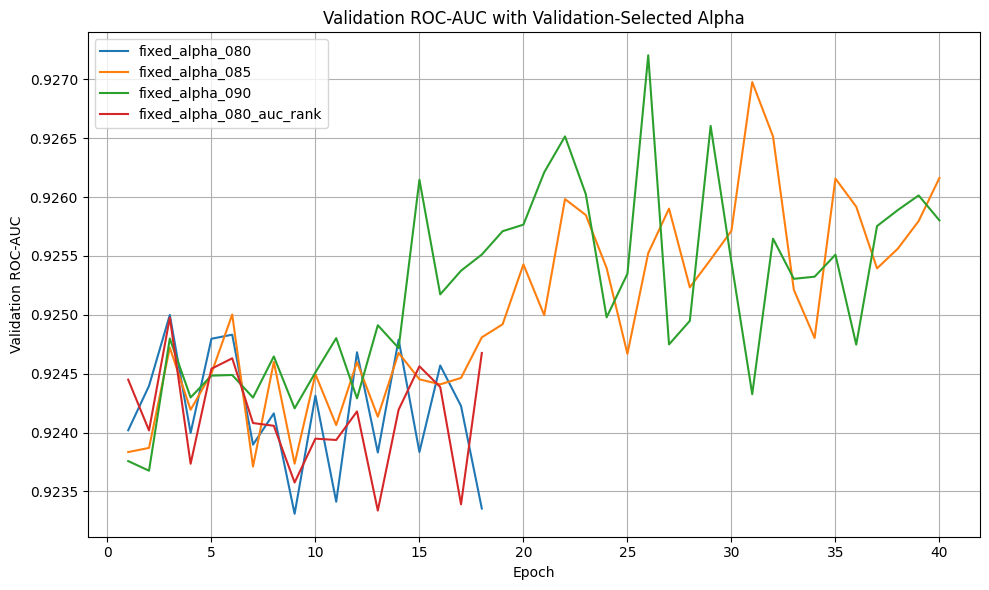

saved plot: ../src/Joint_LGBM_GNN_models/saved_results/plot_validation_pr_auc_trajectories.png


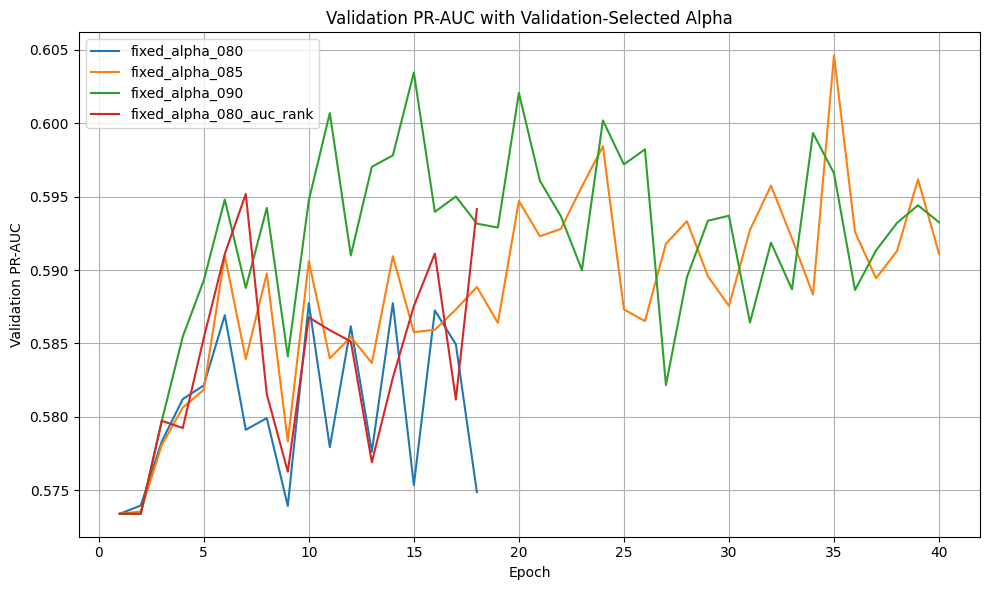

saved plot: ../src/Joint_LGBM_GNN_models/saved_results/plot_standalone_gnn_validation_auc.png


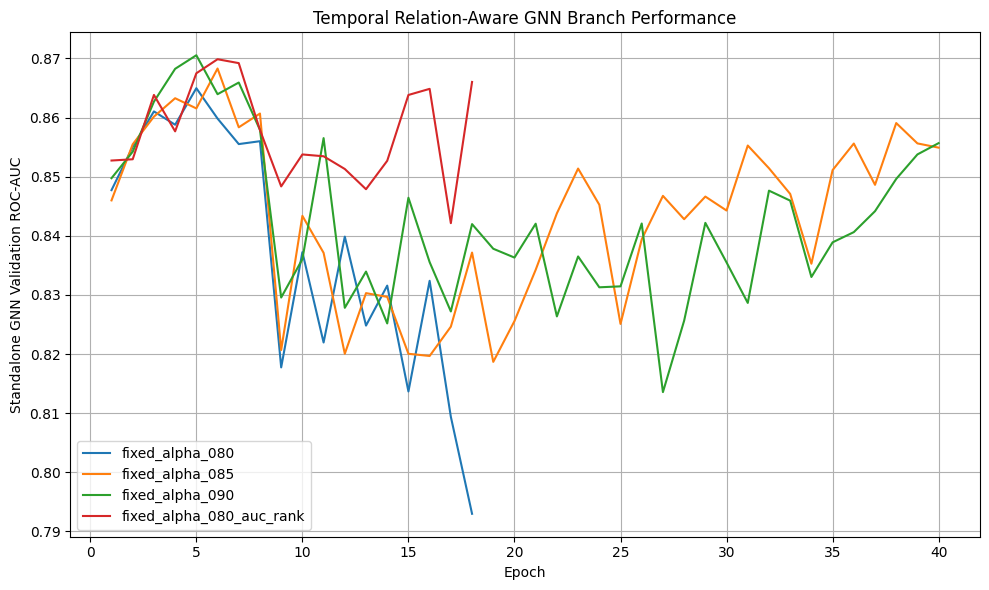

saved plot: ../src/Joint_LGBM_GNN_models/saved_results/plot_validation_selected_alpha_trajectories.png


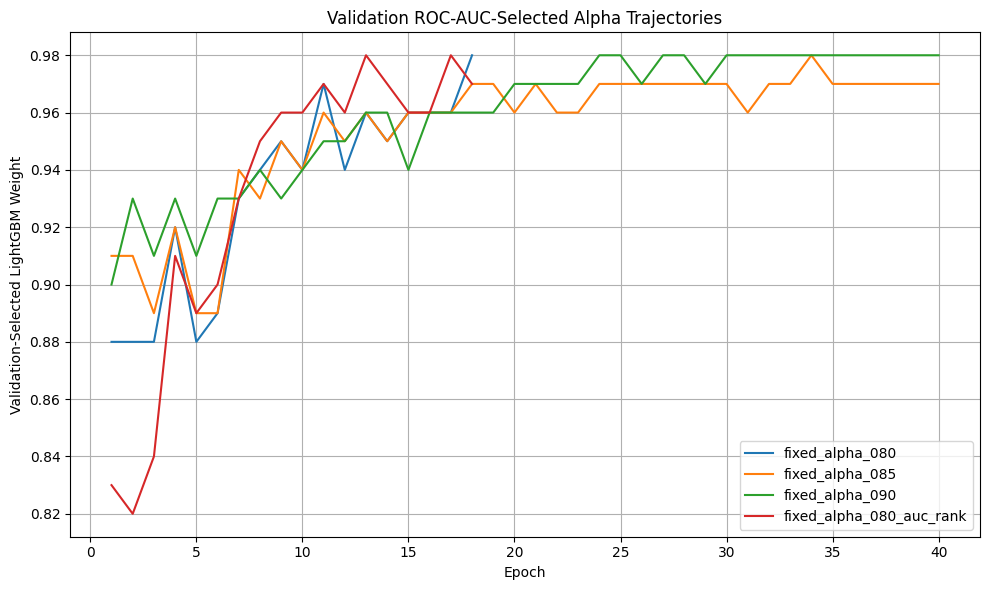

,experiment,fixed_alpha,main_loss_type,best_epoch,best_val_score,best_selected_alpha_auc,best_selected_alpha_pr,restored_alpha_parameter
0,fixed_alpha_080,0.80,bce,3,0.924999,0.88,0.95,0.5
1,fixed_alpha_085,0.85,bce,31,0.926977,0.96,0.96,0.5
2,fixed_alpha_090,0.90,bce,26,0.927204,0.97,0.97,0.5
3,fixed_alpha_080_auc_rank,0.80,pairwise_auc,3,0.924977,0.84,0.91,0.5


In [15]:
# ============================================================
# Cross-run training curves
# ============================================================

if history_df.empty:
    raise ValueError("history_df is empty; no training history is available.")


plot_history_metric(
    history_df,
    "val_auc_selected_auc",
    "Validation ROC-AUC",
    "Validation ROC-AUC with Validation-Selected Alpha",
    "plot_validation_roc_auc_trajectories.png",
    output_dir=RESULTS_DIR,
)

plot_history_metric(
    history_df,
    "val_pr_selected_pr",
    "Validation PR-AUC",
    "Validation PR-AUC with Validation-Selected Alpha",
    "plot_validation_pr_auc_trajectories.png",
    output_dir=RESULTS_DIR,
)

plot_history_metric(
    history_df,
    "val_auc_gnn",
    "Standalone GNN Validation ROC-AUC",
    "Temporal Relation-Aware GNN Branch Performance",
    "plot_standalone_gnn_validation_auc.png",
    output_dir=RESULTS_DIR,
)

plot_history_metric(
    history_df,
    "alpha_selected_auc",
    "Validation-Selected LightGBM Weight",
    "Validation ROC-AUC-Selected Alpha Trajectories",
    "plot_validation_selected_alpha_trajectories.png",
    output_dir=RESULTS_DIR,
)


display(best_checkpoint_summary_df)


## 13. Final untouched test evaluation: LightGBM + four final joint models

The four final fixed-alpha training runs are restored from their validation-selected checkpoints:

- alpha 0.80, BCE fusion objective;
- alpha 0.85, BCE fusion objective;
- alpha 0.90, BCE fusion objective;
- alpha 0.80, pairwise AUC-ranking fusion objective.

Each GNN is evaluated only once on the test loader. The saved test logits are then reused to compute:

- the main result at the validation ROC-AUC-selected inference alpha;
- a sensitivity result at the validation PR-AUC-selected inference alpha;
- a sensitivity result at the fixed training alpha.

The main comparison table contains five rows: LightGBM alone and the four final joint models. Test predictions and metrics are saved to Drive so these plots and tables can be reproduced without rerunning the GNN.



LIGHTGBM TEST METRICS
ROC-AUC: 0.9113150537415661
PR-AUC : 0.5526917488922963

Loading: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_fixed_alpha_080_best.pt
experiment: fixed_alpha_080
training alpha: 0.8
training objective: bce
best epoch: 3
best validation score: 0.9249987200465029
validation-selected AUC alpha: 0.88
validation-selected PR alpha: 0.95

Main test metrics (validation AUC-selected inference alpha):
{'auc_fused': 0.91752838458629, 'pr_fused': 0.55787563940148, 'auc_lgb': 0.9113150537415662, 'pr_lgb': 0.5526916716750573, 'auc_gnn': 0.8495651210188403, 'pr_gnn': 0.3330585075760412, 'alpha': 0.8799999952316284}
PR-alpha sensitivity: {'alpha': 0.95, 'auc_fused': 0.9152985258273464, 'pr_fused': 0.5581436031868073}
training-alpha sensitivity: {'alpha': 0.8, 'auc_fused': 0.917213190427189, 'pr_fused': 0.5454691449414881}
saved test predictions: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_fixed_alpha_080_test_predictions.parquet

Loa

,model,training_objective,training_alpha,inference_alpha,test_roc_auc,test_pr_auc,standalone_gnn_roc_auc,standalone_gnn_pr_auc
0,LightGBM,lightgbm_binary,NaN,1.00,0.911315,0.552692,NaN,NaN
1,fixed_alpha_080,bce,0.80,0.88,0.917528,0.557876,0.849565,0.333059
2,fixed_alpha_085,bce,0.85,0.96,0.910585,0.546015,0.785049,0.160638
3,fixed_alpha_090,bce,0.90,0.97,0.905864,0.549225,0.752101,0.184536
4,fixed_alpha_080_auc_rank,pairwise_auc,0.80,0.84,0.917152,0.559028,0.848566,0.326888



Alpha sensitivity:


,model,training_objective,evaluation_rule,alpha,test_roc_auc,test_pr_auc
0,fixed_alpha_080,bce,validation_auc_selected_alpha,0.88,0.917528,0.557876
1,fixed_alpha_080,bce,validation_pr_selected_alpha,0.95,0.915299,0.558144
2,fixed_alpha_080,bce,fixed_training_alpha,0.80,0.917213,0.545469
3,fixed_alpha_085,bce,validation_auc_selected_alpha,0.96,0.910585,0.546015
4,fixed_alpha_085,bce,validation_pr_selected_alpha,0.96,0.910585,0.546015
5,fixed_alpha_085,bce,fixed_training_alpha,0.85,0.876675,0.445680
6,fixed_alpha_090,bce,validation_auc_selected_alpha,0.97,0.905864,0.549225
7,fixed_alpha_090,bce,validation_pr_selected_alpha,0.97,0.905864,0.549225
8,fixed_alpha_090,bce,fixed_training_alpha,0.90,0.874974,0.467420
9,fixed_alpha_080_auc_rank,pairwise_auc,validation_auc_selected_alpha,0.84,0.917152,0.559028


saved test comparison: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_test_comparison.csv
saved alpha sensitivity: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_test_alpha_sensitivity.csv
saved all test predictions: ../src/Joint_LGBM_GNN_models/saved_results/temporal_relation_aware_test_predictions_all_final_runs.parquet
saved ROC plot: ../src/Joint_LGBM_GNN_models/saved_results/plot_untouched_test_roc_curves.png


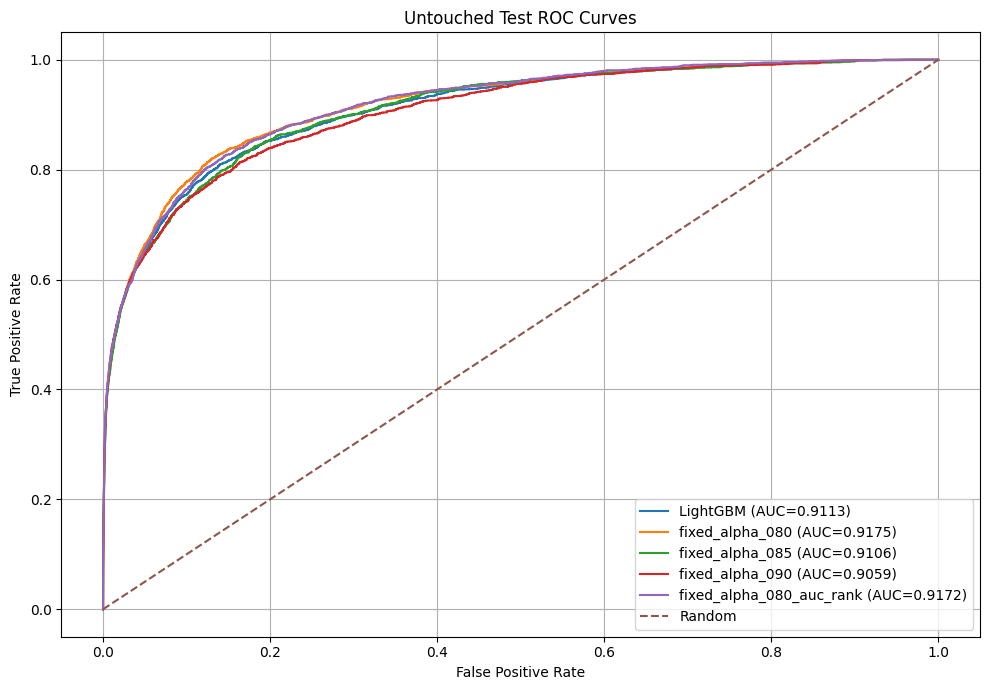

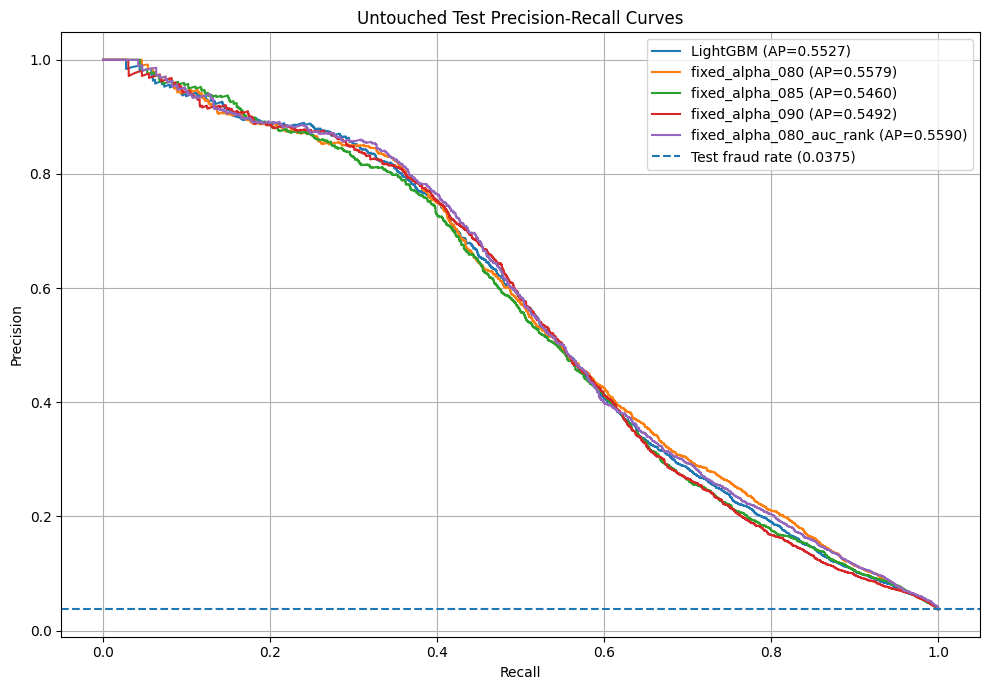

In [16]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
)


checkpoint_paths = [
    RESULTS_DIR / "temporal_relation_aware_fixed_alpha_080_best.pt",
    RESULTS_DIR / "temporal_relation_aware_fixed_alpha_085_best.pt",
    RESULTS_DIR / "temporal_relation_aware_fixed_alpha_090_best.pt",
    RESULTS_DIR / "temporal_relation_aware_fixed_alpha_080_auc_rank_best.pt",
]


# ------------------------------------------------------------
# Verify all expected checkpoints exist before test evaluation
# ------------------------------------------------------------
missing_checkpoints = [
    str(path)
    for path in checkpoint_paths
    if not path.exists()
]

if missing_checkpoints:
    raise FileNotFoundError(
        "Missing checkpoint(s):\n"
        + "\n".join(missing_checkpoints)
    )


# ============================================================
# LightGBM test result
# ============================================================
test_y = y_all[test_idx_np].astype(np.int64)
lgb_test_prob = lgb_prob_fullfit_all[test_idx_np]

lgb_test_auc = safe_auc(
    test_y,
    lgb_test_prob,
)

lgb_test_pr = safe_pr_auc(
    test_y,
    lgb_test_prob,
)

print("\n" + "=" * 88)
print("LIGHTGBM TEST METRICS")
print("=" * 88)
print("ROC-AUC:", lgb_test_auc)
print("PR-AUC :", lgb_test_pr)


comparison_rows = [
    {
        "model": "LightGBM",
        "training_objective": "lightgbm_binary",
        "training_alpha": np.nan,
        "inference_alpha": 1.0,
        "test_roc_auc": lgb_test_auc,
        "test_pr_auc": lgb_test_pr,
        "standalone_gnn_roc_auc": np.nan,
        "standalone_gnn_pr_auc": np.nan,
    }
]

alpha_sensitivity_rows = []
all_test_prediction_frames = []

curve_predictions = {
    "LightGBM": {
        "y_true": test_y,
        "score": lgb_test_prob,
    }
}


# ============================================================
# Evaluate the four final fixed-alpha trained joint models
# ============================================================
for checkpoint_path in checkpoint_paths:

    print("\n" + "=" * 88)
    print("Loading:", checkpoint_path)
    print("=" * 88)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    config = checkpoint.get(
        "model_config",
        {},
    )

    loaded_model = (
        JointLightGBMTemporalRelationAwareGraphSAGE(
            sage_input_dim=int(
                config.get(
                    "sage_input_dim",
                    X_sage_all.shape[1],
                )
            ),
            num_topology_features=int(
                config.get(
                    "num_topology_features",
                    NUM_TOPOLOGY_FEATURES,
                )
            ),
            relation_names=checkpoint.get(
                "graph_relation_names",
                GRAPH_RELATION_NAMES,
            ),
            hidden_dim=int(
                config.get(
                    "hidden_dim",
                    GNN_HIDDEN_DIM,
                )
            ),
            dropout_p=float(
                config.get(
                    "dropout_p",
                    GNN_DROPOUT,
                )
            ),
            attention_hidden_dim=int(
                config.get(
                    "attention_hidden_dim",
                    RELATION_ATTENTION_HIDDEN_DIM,
                )
            ),
            alpha_init=float(
                config.get(
                    "alpha_init",
                    ALPHA_INIT,
                )
            ),
        )
        .to(device)
    )

    loaded_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    loaded_model.eval()

    experiment_name = checkpoint[
        "experiment_name"
    ]

    train_alpha = float(
        checkpoint["fixed_alpha"]
    )

    main_loss_type = checkpoint.get(
        "main_loss_type",
        checkpoint.get("training_config", {}).get(
            "main_loss_type",
            "bce",
        ),
    )

    auc_alpha = float(
        checkpoint["best_selected_alpha_auc"]
    )

    pr_alpha = float(
        checkpoint["best_selected_alpha_pr"]
    )

    print("experiment:", experiment_name)
    print("training alpha:", train_alpha)
    print("training objective:", main_loss_type)
    print("best epoch:", checkpoint["best_epoch"])
    print("best validation score:", checkpoint["best_val_score"])
    print("validation-selected AUC alpha:", auc_alpha)
    print("validation-selected PR alpha:", pr_alpha)


    # --------------------------------------------------------
    # One GNN test pass only.
    # The logits are reused for all alpha sensitivity checks.
    # --------------------------------------------------------
    auc_metrics, test_pred = evaluate_loader(
        loaded_model,
        test_loader,
        device,
        alpha_override=auc_alpha,
    )


    # Validation-PR-selected alpha, recomputed from saved logits.
    pr_alpha_metrics = fusion_metrics_from_pred_df(
        test_pred,
        pr_alpha,
    )


    # Fixed training alpha, recomputed from saved logits.
    train_alpha_metrics = fusion_metrics_from_pred_df(
        test_pred,
        train_alpha,
    )


    print("\nMain test metrics (validation AUC-selected inference alpha):")
    print({
        "auc_fused": auc_metrics["auc_fused"],
        "pr_fused": auc_metrics["pr_fused"],
        "auc_lgb": auc_metrics["auc_lgb"],
        "pr_lgb": auc_metrics["pr_lgb"],
        "auc_gnn": auc_metrics["auc_gnn"],
        "pr_gnn": auc_metrics["pr_gnn"],
        "alpha": auc_metrics["alpha"],
    })

    print(
        "PR-alpha sensitivity:",
        {
            "alpha": pr_alpha,
            "auc_fused": pr_alpha_metrics["auc"],
            "pr_fused": pr_alpha_metrics["pr"],
        },
    )

    print(
        "training-alpha sensitivity:",
        {
            "alpha": train_alpha,
            "auc_fused": train_alpha_metrics["auc"],
            "pr_fused": train_alpha_metrics["pr"],
        },
    )


    # --------------------------------------------------------
    # Main four-model comparison row
    # --------------------------------------------------------
    comparison_rows.append({
        "model": experiment_name,
        "training_objective": main_loss_type,
        "training_alpha": train_alpha,
        "inference_alpha": auc_alpha,
        "test_roc_auc": auc_metrics["auc_fused"],
        "test_pr_auc": auc_metrics["pr_fused"],
        "standalone_gnn_roc_auc": auc_metrics["auc_gnn"],
        "standalone_gnn_pr_auc": auc_metrics["pr_gnn"],
    })


    # --------------------------------------------------------
    # Alpha sensitivity table
    # --------------------------------------------------------
    alpha_sensitivity_rows.extend([
        {
            "model": experiment_name,
            "training_objective": main_loss_type,
            "evaluation_rule": "validation_auc_selected_alpha",
            "alpha": auc_alpha,
            "test_roc_auc": auc_metrics["auc_fused"],
            "test_pr_auc": auc_metrics["pr_fused"],
        },
        {
            "model": experiment_name,
            "training_objective": main_loss_type,
            "evaluation_rule": "validation_pr_selected_alpha",
            "alpha": pr_alpha,
            "test_roc_auc": pr_alpha_metrics["auc"],
            "test_pr_auc": pr_alpha_metrics["pr"],
        },
        {
            "model": experiment_name,
            "training_objective": main_loss_type,
            "evaluation_rule": "fixed_training_alpha",
            "alpha": train_alpha,
            "test_roc_auc": train_alpha_metrics["auc"],
            "test_pr_auc": train_alpha_metrics["pr"],
        },
    ])


    # --------------------------------------------------------
    # Save per-node predictions for future plotting/analysis
    # --------------------------------------------------------
    test_pred = add_fused_probability(
        test_pred,
        auc_alpha,
        column_name="pred_fused_auc_selected",
    )

    test_pred = add_fused_probability(
        test_pred,
        pr_alpha,
        column_name="pred_fused_pr_selected",
    )

    test_pred = add_fused_probability(
        test_pred,
        train_alpha,
        column_name="pred_fused_training_alpha",
    )

    test_pred.insert(
        0,
        "experiment",
        experiment_name,
    )

    test_pred.insert(
        1,
        "training_objective",
        main_loss_type,
    )

    node_id_values = test_pred[
        "node_id"
    ].to_numpy(dtype=np.int64)

    test_pred.insert(
        2,
        "TransactionID",
        df_sorted.iloc[
            node_id_values
        ]["TransactionID"].to_numpy(),
    )

    test_pred_path = (
        RESULTS_DIR
        / f"temporal_relation_aware_{experiment_name}_test_predictions.parquet"
    )

    test_pred.to_parquet(
        test_pred_path,
        index=False,
    )

    print("saved test predictions:", test_pred_path)

    all_test_prediction_frames.append(
        test_pred
    )

    curve_predictions[experiment_name] = {
        "y_true": test_pred["isFraud"].to_numpy(),
        "score": test_pred[
            "pred_fused_auc_selected"
        ].to_numpy(),
    }


    # Free GPU memory before loading the next checkpoint.
    del loaded_model
    del checkpoint

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# Save test tables and all test predictions
# ============================================================
test_comparison_df = pd.DataFrame(
    comparison_rows
)

alpha_sensitivity_df = pd.DataFrame(
    alpha_sensitivity_rows
)

all_test_predictions_df = pd.concat(
    all_test_prediction_frames,
    ignore_index=True,
)


test_comparison_path = (
    RESULTS_DIR
    / "temporal_relation_aware_test_comparison.csv"
)

alpha_sensitivity_path = (
    RESULTS_DIR
    / "temporal_relation_aware_test_alpha_sensitivity.csv"
)

all_test_predictions_path = (
    RESULTS_DIR
    / "temporal_relation_aware_test_predictions_all_final_runs.parquet"
)


test_comparison_df.to_csv(
    test_comparison_path,
    index=False,
)

alpha_sensitivity_df.to_csv(
    alpha_sensitivity_path,
    index=False,
)

all_test_predictions_df.to_parquet(
    all_test_predictions_path,
    index=False,
)


print("\n" + "=" * 88)
print("MAIN TEST COMPARISON")
print("=" * 88)
display(test_comparison_df)

print("\nAlpha sensitivity:")
display(alpha_sensitivity_df)

print("saved test comparison:", test_comparison_path)
print("saved alpha sensitivity:", alpha_sensitivity_path)
print("saved all test predictions:", all_test_predictions_path)


# ============================================================
# Test ROC curves
# ============================================================
plt.figure(figsize=(10, 7))

for model_name, item in curve_predictions.items():
    fpr, tpr, _ = roc_curve(
        item["y_true"],
        item["score"],
    )

    auc_value = safe_auc(
        item["y_true"],
        item["score"],
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_value:.4f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Untouched Test ROC Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
roc_plot_path = RESULTS_DIR / "plot_untouched_test_roc_curves.png"
plt.savefig(
    roc_plot_path,
    dpi=200,
    bbox_inches="tight",
)
print("saved ROC plot:", roc_plot_path)
plt.show()


# ============================================================
# Test precision-recall curves
# ============================================================
plt.figure(figsize=(10, 7))

for model_name, item in curve_predictions.items():
    precision, recall, _ = precision_recall_curve(
        item["y_true"],
        item["score"],
    )

    pr_value = safe_pr_auc(
        item["y_true"],
        item["score"],
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP={pr_value:.4f})",
    )

test_fraud_rate = float(
    np.mean(test_y)
)

plt.axhline(
    test_fraud_rate,
    linestyle="--",
    label=f"Test fraud rate ({test_fraud_rate:.4f})",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Untouched Test Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()